# 神經機器翻譯(NMT)

## 載入相關套件

In [1]:
from __future__ import division, print_function, unicode_literals

from typing import cast
import math
import random
import re
import time
import unicodedata
from io import open

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from torch import nn
from torch.nn import functional as F
from torch import optim

## 判斷GPU是否存在

In [2]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 文字的前置處理函數

In [3]:
SOS_token = 0  # 字句的開頭加一標誌
EOS_token = 1  # 字句的結尾加一標誌


# 前置處理函數
class Lang:
    def __init__(self, name: str):
        self.name = name
        self.word2index = {}  # 單字轉代碼的字典
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS"}  # 代碼轉單字的字典
        self.n_words = 2  # Count SOS and EOS

    def addSentence(self, sentence: str):  # 建立詞彙表
        for word in sentence.split(' '):
            self.addWord(word)  # 分詞

    def addWord(self, word: str):  # 建立詞彙表
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

In [4]:
# Unicode 轉 ASCII
# https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s: str):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')


# 轉小寫、去除前後的空白、去除標點符號
def normalizeString(s: str):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s

In [5]:
# 讀取檔案
def readLangs(lang1: str, lang2: str, reverse=False):
    print("Reading lines...")

    # 讀取檔案、分行
    lines = open(f'nlp_data/{lang1}-{lang2}.txt', encoding='utf-8').read().strip().split('\n')

    # 每行分欄
    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]

    # 法文翻譯為英文，或反向
    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs

In [6]:
# 每句只限翻譯 10 個單字
MAX_LENGTH = 10

# 特殊縮寫字對照表
eng_prefixes = (
    "i am ",
    "i m ",
    "he is",
    "he s ",
    "she is",
    "she s ",
    "you are",
    "you re ",
    "we are",
    "we re ",
    "they are",
    "they re ",
)


# 超過 10 個單字的字句刪除
def filterPair(p: list[str]):
    return len(p[0].split(' ')) < MAX_LENGTH and len(p[1].split(' ')) < MAX_LENGTH and p[1].startswith(eng_prefixes)


def filterPairs(pairs: list[list[str]]):
    return [pair for pair in pairs if filterPair(pair)]

In [7]:
# 前置處理：整合以上函數
def prepareData(lang1: str, lang2: str, reverse=False):
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    print("Read %s sentence pairs" % len(pairs))
    pairs = filterPairs(pairs)
    print("Trimmed to %s sentence pairs" % len(pairs))
    print("Counting words...")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, pairs


# eng-fra.txt檔案讀取與處理
input_lang, output_lang, pairs = prepareData('eng', 'fra', True)
# 隨機顯示一筆
print(random.choice(pairs))

Reading lines...
Read 135842 sentence pairs
Trimmed to 10599 sentence pairs
Counting words...
Counted words:
fra 4345
eng 2803
['il est occupe a apprendre l anglais .', 'he is busy learning english .']


## 建立Seq2Seq 模型

### Encoder

In [8]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size: int, hidden_size: int):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, input: torch.Tensor, hidden: torch.Tensor):
        embedded = cast(torch.Tensor, self.embedding(input)).view(1, 1, -1)
        output = embedded
        output, hidden = self.gru(output, hidden)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

### Decoder

In [9]:
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size: int, output_size: int):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input: torch.Tensor, hidden: torch.Tensor):
        output = cast(torch.Tensor, self.embedding(input)).view(1, 1, -1)
        output = F.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.softmax(self.out(output[0]))
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

### Attention Decoder

In [ ]:
class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size: int, output_size: int, dropout_p=0.1, max_length=MAX_LENGTH):
        super(AttnDecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.dropout_p = dropout_p
        self.max_length = max_length

        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attn = nn.Linear(hidden_size * 2, max_length)
        self.attn_combine = nn.Linear(hidden_size * 2, hidden_size)
        self.dropout = nn.Dropout(dropout_p)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, input: torch.Tensor, hidden: torch.Tensor, encoder_outputs: torch.Tensor):
        embedded = cast(torch.Tensor, self.embedding(input)).view(1, 1, -1)
        embedded = self.dropout(embedded)

        attn_weights = F.softmax(self.attn(torch.cat((embedded[0], hidden[0]), dim=1)), dim=1)
        attn_applied = torch.bmm(attn_weights.unsqueeze(0), encoder_outputs.unsqueeze(0))

        output = torch.cat((embedded[0], attn_applied[0]), dim=1)
        output = cast(torch.Tensor, self.attn_combine(output)).unsqueeze(0)

        output = F.relu(output)
        output, hidden = self.gru(output, hidden)

        output = F.log_softmax(self.out(output[0]), dim=1)
        return output, hidden, attn_weights

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

## 張量轉換函數

In [11]:
def indexesFromSentence(lang: Lang, sentence: str):
    return [lang.word2index[word] for word in sentence.split(' ')]


def tensorFromSentence(lang: Lang, sentence: str):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)


def tensorsFromPair(pair: list[str]):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)

## 模型訓練函數

In [ ]:
teacher_forcing_ratio = 0.5  # 採用 Teacher Forcing 的機率


def train(
    input_tensor: torch.Tensor,
    target_tensor: torch.Tensor,
    encoder: EncoderRNN,
    decoder: AttnDecoderRNN,
    encoder_optimizer: optim.Optimizer,
    decoder_optimizer: optim.Optimizer,
    criterion: nn.Module,
    max_length=MAX_LENGTH,
):
    encoder_hidden = encoder.initHidden()

    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)

    encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

    loss = torch.tensor(0.0, device=device)

    for ei in range(input_length):
        print(f"input_tensor[ei]: {input_tensor[ei]}")
        print(f"encoder_hidden: {encoder_hidden}")
        encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
        encoder_outputs[ei] = encoder_output[0, 0]

    decoder_input = torch.tensor([[SOS_token]], device=device)

    decoder_hidden = encoder_hidden

    # 取隨機亂數，決定是否採用 Teacher Forcing
    use_teacher_forcing = random.random() < teacher_forcing_ratio

    # Teacher Forcing 模式
    if use_teacher_forcing:
        for di in range(target_length):
            decoder_output, decoder_hidden, decoder_attention = decoder(decoder_input, decoder_hidden, encoder_outputs)
            loss += criterion(decoder_output, target_tensor[di])
            # 以上一步驟的實際標註(Y)，作為下一步驟的輸入
            decoder_input = target_tensor[di]

    else:  # Free-Running 模式
        for di in range(target_length):
            decoder_output, decoder_hidden, decoder_attention = decoder(decoder_input, decoder_hidden, encoder_outputs)
            topv, topi = decoder_output.topk(1)
            # 以上一步驟的隱藏層輸出，作為下一步驟的輸入
            decoder_input = topi.squeeze().detach()

            loss += criterion(decoder_output, target_tensor[di])
            if decoder_input.item() == EOS_token:
                break

    loss.backward()

    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_length

## 計算執行時間的函數

In [13]:
# 換算為分鐘
def asMinutes(s: float):
    m = math.floor(s / 60)
    s -= m * 60
    return f'{m}m {s}s'


# 計算執行時間
def timeSince(since: float, percent: float):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return f'{asMinutes(s)} (- {asMinutes(rs)})'

## 定義訓練週期函數：整合以上函數

In [ ]:
def trainIters(encoder: EncoderRNN, decoder:AttnDecoderRNN, n_iters: int, print_every=1_000, plot_every=100, learning_rate=0.01):
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # 初始化列印的損失值
    plot_loss_total = 0  # 初始化繪製的損失值

    # 定義優化器、損失函數
    encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
    training_pairs = [tensorsFromPair(random.choice(pairs)) for i in range(n_iters)]
    criterion = nn.NLLLoss()

    # 訓練週期
    for iter in range(1, n_iters + 1):
        training_pair = training_pairs[iter - 1]
        input_tensor = training_pair[0]
        target_tensor = training_pair[1]

        loss = train(input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss
        plot_loss_total += loss

        if iter % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print(f'{timeSince(start, iter / n_iters)}' + f' ({iter} {iter / n_iters * 100}%) {print_loss_avg:.4f}')

        if iter % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

    showPlot(plot_losses)

## 定義繪圖函數

In [15]:
def showPlot(points: list[float]):
    plt.figure()
    fig, ax = plt.subplots()
    # this locator puts ticks at regular intervals
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)
    plt.show()

## 定義模型評估函數

In [16]:
def evaluate(encoder: EncoderRNN, decoder: AttnDecoderRNN, sentence: str, max_length=MAX_LENGTH):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)
        input_length = input_tensor.size()[0]
        encoder_hidden = encoder.initHidden()

        encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            encoder_outputs[ei] += encoder_output[0, 0]

        decoder_input = torch.tensor([[SOS_token]], device=device)  # SOS

        decoder_hidden = encoder_hidden

        decoded_words: list[str] = []
        decoder_attentions = torch.zeros(max_length, max_length)

        di = 0
        for di in range(max_length):
            decoder_output, decoder_hidden, decoder_attention = decoder(decoder_input, decoder_hidden, encoder_outputs)
            decoder_attentions[di] = decoder_attention.data
            topv, topi = decoder_output.data.topk(1)
            if topi.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            else:
                decoded_words.append(output_lang.index2word[topi.item()])

            decoder_input = topi.squeeze().detach()

        return decoded_words, decoder_attentions[: di + 1]

## 模型訓練：GTX 1050 Ti 約70分鐘

1m 35.97823119163513s (- 22m 23.695236682891846s) (5000 6.666666666666667%) 2.8862
2m 51.11941885948181s (- 18m 32.276222586631775s) (10000 13.333333333333334%) 2.2874
4m 6.886255979537964s (- 16m 27.545023918151855s) (15000 20.0%) 1.9698
5m 25.16238498687744s (- 14m 54.196558713912964s) (20000 26.666666666666668%) 1.7076
6m 40.832103967666626s (- 13m 21.664207935333252s) (25000 33.33333333333333%) 1.4916
7m 56.140406131744385s (- 11m 54.21060919761658s) (30000 40.0%) 1.3628
9m 12.253545045852661s (- 10m 31.146908623831678s) (35000 46.666666666666664%) 1.2144
10m 29.218744039535522s (- 9m 10.566401034593582s) (40000 53.333333333333336%) 1.0844
11m 44.724404096603394s (- 7m 49.816269397735596s) (45000 60.0%) 0.9941
13m 0.3824341297149658s (- 6m 30.191217064857483s) (50000 66.66666666666666%) 0.8919
14m 15.843214988708496s (- 5m 11.215714541348689s) (55000 73.33333333333333%) 0.7893
15m 31.276688814163208s (- 3m 52.8191722035408s) (60000 80.0%) 0.7347
16m 46.819002866744995s (- 2m 34.895

<Figure size 640x480 with 0 Axes>

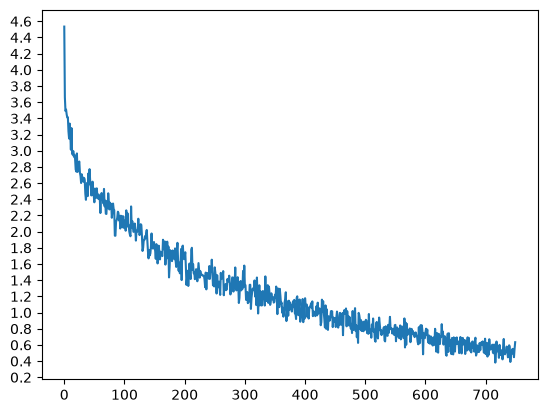

In [17]:
hidden_size = 256
encoder1 = EncoderRNN(input_lang.n_words, hidden_size).to(device)
attn_decoder1 = AttnDecoderRNN(hidden_size, output_lang.n_words, dropout_p=0.1).to(device)

trainIters(encoder1, attn_decoder1, 75000, print_every=5000)

## 任選10筆訓練資料評估  

In [18]:
def evaluateRandomly(encoder: EncoderRNN, decoder: AttnDecoderRNN, n=10):
    for i in range(n):
        pair = random.choice(pairs)
        print('>', pair[0])
        print('=', pair[1])
        output_words, attentions = evaluate(encoder, decoder, pair[0])
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')


evaluateRandomly(encoder1, attn_decoder1)

> nous sommes canadiennes .
= we re canadians .
< we re on . <EOS>

> je suis etonne par ton audace .
= i am amazed at your audacity .
< i am amazed at your audacity . <EOS>

> je ne suis pas fou .
= i m not crazy .
< i m not crazy . <EOS>

> elle nous enseigne le francais .
= she s teaching us french .
< she s teaching us french . <EOS>

> je suis prete a tout faire pour toi .
= i am ready to do anything for you .
< i am ready to do anything for you . <EOS>

> je ne suis pas du tout fatigue .
= i m not at all tired .
< i m not tired at all . <EOS>

> de toute facon on va tous mourir .
= we re all going to die anyway .
< we re going to to be ok to die .

> il se rapproche .
= he s coming closer .
< he s getting closer . <EOS>

> nous enquetons a ce sujet .
= we re investigating it .
< we re starting about that . <EOS>

> tu as toujours quelque chose a me reprocher .
= you are always finding fault with me .
< you are always finding fault with me . <EOS>



## Attention 視覺化

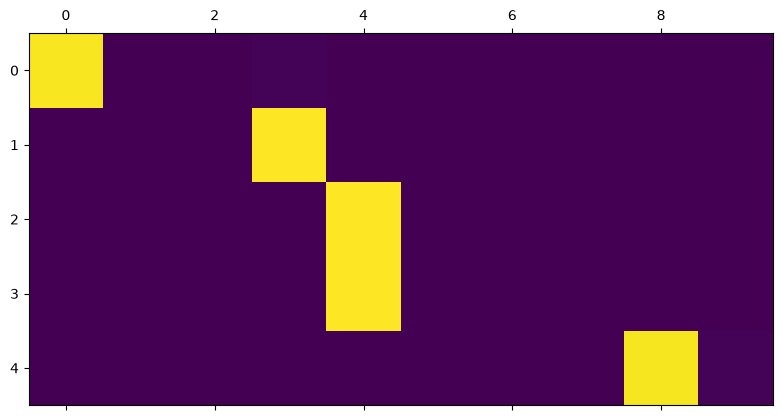

In [19]:
output_words, attentions = evaluate(encoder1, attn_decoder1, "je suis trop froid .")
plt.matshow(attentions.numpy())

## Attention 視覺化加強版

input = elle a cinq ans de moins que moi .
output = she is five years younger than i . <EOS>


/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_56450/1867664346.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([''] + input_sentence.split(' ') + ['<EOS>'], rotation=90)
/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_56450/1867664346.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([''] + output_words)


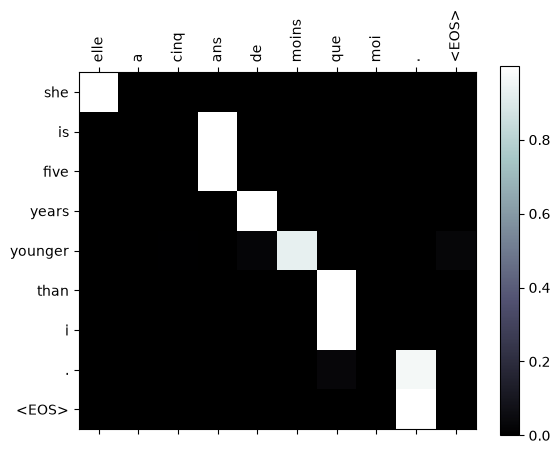

input = elle est trop petit .
output = she s too busy . <EOS>


/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_56450/1867664346.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([''] + input_sentence.split(' ') + ['<EOS>'], rotation=90)
/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_56450/1867664346.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([''] + output_words)


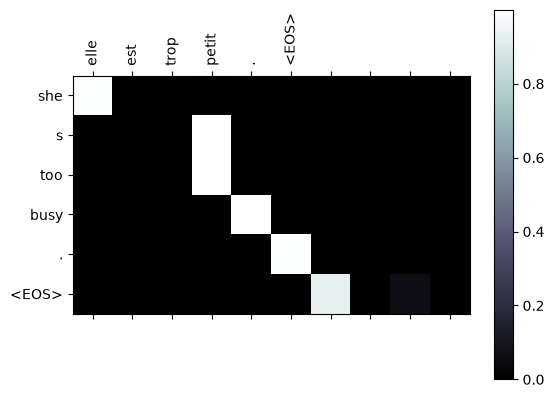

input = je ne crains pas de mourir .
output = i m not afraid to death . <EOS>


/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_56450/1867664346.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([''] + input_sentence.split(' ') + ['<EOS>'], rotation=90)
/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_56450/1867664346.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([''] + output_words)


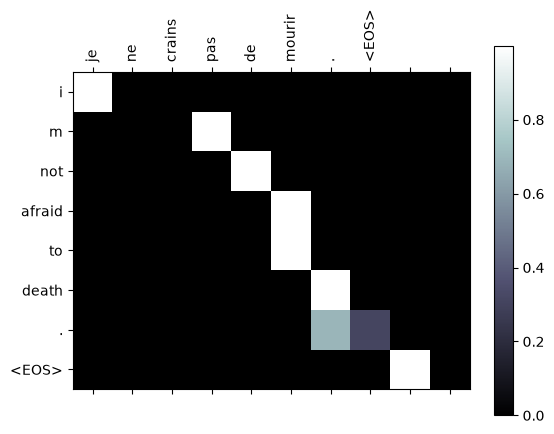

input = c est un jeune directeur plein de talent .
output = he is a bit young . <EOS>


/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_56450/1867664346.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([''] + input_sentence.split(' ') + ['<EOS>'], rotation=90)
/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_56450/1867664346.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([''] + output_words)


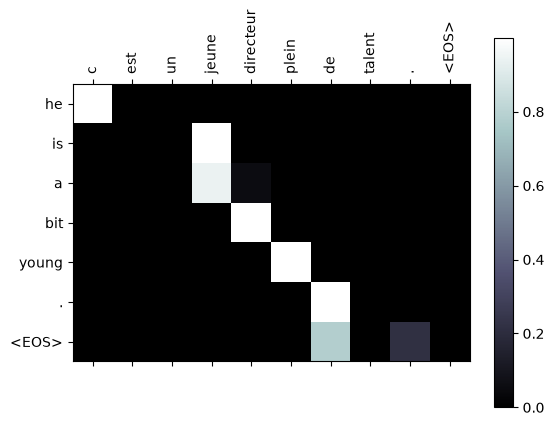

In [20]:
def showAttention(input_sentence: str, output_words: list[str], attentions: torch.Tensor):
    # Set up figure with colorbar
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.numpy(), cmap='bone')
    fig.colorbar(cax)

    # Set up axes
    ax.set_xticklabels([''] + input_sentence.split(' ') + ['<EOS>'], rotation=90)
    ax.set_yticklabels([''] + output_words)

    # Show label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()


def evaluateAndShowAttention(input_sentence: str):
    output_words, attentions = evaluate(encoder1, attn_decoder1, input_sentence)
    print('input =', input_sentence)
    print('output =', ' '.join(output_words))
    showAttention(input_sentence, output_words, attentions)


# 測試4句法文
evaluateAndShowAttention("elle a cinq ans de moins que moi .")
evaluateAndShowAttention("elle est trop petit .")
evaluateAndShowAttention("je ne crains pas de mourir .")
evaluateAndShowAttention("c est un jeune directeur plein de talent .")